# **USML Strategy Learning Statistical Analysis**

---

### Condition Groups

| Group | Description | Label |
|-------|-------------|-------|
| Self-learning | Control group (no explanations) | $H_1$ |
| Machine-explained learning | Long explanation condition | $H_2$ |
| Human-explained learning | Short explanation condition | $H_r$ |

In [1]:
import itertools
import json
import os
import sys
import warnings

# Ensure the notebook's directory is in the Python path for local imports
_notebook_dir = os.path.dirname(os.path.abspath("__file__"))
if os.path.basename(_notebook_dir) != "data_anlysis":
    _notebook_dir = os.path.join(os.getcwd(), "empirical_study", "data_anlysis")
if _notebook_dir not in sys.path:
    sys.path.insert(0, _notebook_dir)

import numpy as np
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns

from DirectedGraph import DirectedGraph

# Set up matplotlib for publication-quality plots
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman', 'Times New Roman'],
    'mathtext.fontset': 'dejavuserif',
    'figure.figsize': (8, 4.2),
    'figure.dpi': 100,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    # PGF settings for LaTeX export
    'pgf.texsystem': 'pdflatex',
    'pgf.rcfonts': False,
})
sns.set_theme(style="whitegrid", font="DejaVu Serif")

PALETTE = "pastel"
# Color palette for all plots (try: "pastel", "muted", "deep", "colorblind", "tab10")

DOMAIN_NAMES = {
    "circuits": "Electrical Circuits",
    "flow": "Waterflow",
    "lists": "List Binary Search",
}

CONDITION_NAMES = {
    "H1": r"$H_1$ (Self Learning)",
    "Hr": r"$H_r$ (Human Explained)",
    "H2": r"$H_2$ (Machine Explained)",
}

# Short labels for filtering (without description)
CONDITION_LABELS = {
    "H1": r"$H_1$",
    "Hr": r"$H_r$",
    "H2": r"$H_2$",
}

# Canonical order for conditions: Control, Machine/Long, Human/Short
CONDITION_ORDER = ["H1", "H2", "Hr"]

In [2]:
pd.set_option("future.no_silent_downcasting", True)

metric_options: list[str] = ["ig", "mp"]

metric_choice = metric_options[
    int(
        input(
            "choose evaluation metric: Information Gain (0) or Minority Partition (1)"
        )
    )
]

modifications = {
    "rescale_top",
    "exclude_t>121",
    # "replace_missing_with_0",
    "exclude_missing",
    "save",
}

## **Data Preprocessing**

### **Load Data**

In [3]:
dropcols_demographic = [
    "Submission id",
    "Status",
    "Custom study tncs accepted at",
    "Started at",
    "Completed at",
    "Reviewed at",
    "Archived at",
    "Completion code",
    "Total approvals",
    "Ethnicity simplified",
    "Country of birth",
    "Country of residence",
    "Nationality",
    "Language",
    "Student status",
    "Employment status",
]

dropcols_data = [
    "CASE",
    "SERIAL",
    "REF",
    "QUESTNNR",
    "MODE",
    "STARTED",
    "RD02_CP",
    "RD02",
    "RD03_CP",
    "RD03",
    "SD11_10",
    "MAILSENT",
    "LASTDATA",
    "STATUS",
    "FINISHED",
    "Q_VIEWER",
    "LASTPAGE",
    "MAXPAGE",
    "MISSING",
    "MISSREL",
    "DI08",
    "DI13",
    "DI14",
    "LP02",
    "SC01",
    # "SD19_01",
    "TIME018",
    "TIME016",
    "TIME010",
    "TIME006",
    "TIME003",
    "TIME001",
]

In [4]:
demographic1 = pd.read_csv("empirical_study/data_anlysis/data/demographic-first-batch.csv")
demographic1 = demographic1[demographic1["Status"] == "APPROVED"]
demographic1 = demographic1.drop(dropcols_demographic, axis=1)

data1 = pd.read_csv("empirical_study/data_anlysis/data/data-first-batch.csv")
data1["SD19_01"] = [id.strip() for id in data1["SD19_01"].astype(str)]
data1 = data1[
    [
        code in demographic1["Participant id"].astype("str").values
        for code in data1["SD19_01"].astype("str").values
    ]
]
data1 = data1.drop_duplicates(
    "SD19_01"
)  # this one woman -- for whatever reason -- ran the study TWICE
data1["t_total_calc"] = data1["LASTDATA"].astype("datetime64[s]") - data1[
    "STARTED"
].astype("datetime64[s]")
data1["t_total_calc"] = data1["t_total_calc"].astype(int)
data1 = data1.drop(dropcols_data, axis=1)

demographic1 = demographic1.rename({"Participant id": "participant_id"}, axis=1)
demographic1["participant_id"] = demographic1["participant_id"].astype(str)
data1 = data1.rename({"SD19_01": "participant_id"}, axis=1)

In [5]:
demographic2 = pd.read_csv("empirical_study/data_anlysis/data/demographic-second-batch.csv")
demographic2 = demographic2[demographic2["Status"] == "APPROVED"]
demographic2 = demographic2.drop(dropcols_demographic, axis=1)

data2 = pd.read_csv("empirical_study/data_anlysis/data/data-second-batch.csv")
data2["SD19_01"] = [id.strip() for id in data2["SD19_01"].astype(str)]
data2 = data2[
    [
        code in demographic2["Participant id"].astype("str").values
        for code in data2["SD19_01"].astype("str").values
    ]
]

data2 = data2.drop([
    230,
    329,
])  # re-started the study before being kicked out, most likely due to not being able to go back to the instructions
data2 = data2.drop([
    152
])  # !!! noticed attention check and then re-started before failing it and getting kicked out

data2.loc[340, "SD02_01"] = (
    demographic2
    .loc[demographic2["Participant id"] == data2.loc[340, "SD19_01"], "Age"]
    .astype(int)
    .item()
)  # did not report their age in our questionnaire, but on prolific
data2.loc[232, "TR22"] = -1

data2 = data2.drop_duplicates("SD19_01")
data2["t_total_calc"] = data2["LASTDATA"].astype("datetime64[s]") - data2[
    "STARTED"
].astype("datetime64[s]")
data2["t_total_calc"] = data2["t_total_calc"].astype(int)
data2 = data2.drop(dropcols_data, axis=1)

demographic2 = demographic2.rename({"Participant id": "participant_id"}, axis=1)
demographic2["participant_id"] = demographic2["participant_id"].astype(str)
data2 = data2.rename({"SD19_01": "participant_id"}, axis=1)

In [6]:
data = pd.concat((data1, data2))
demographic = pd.concat((demographic1, demographic2))

assert len(data) == 150, "We seem to have lost some records..."

### **Prepare Data**

In [7]:
data["IV01_01"] = pd.Categorical(
    data["IV01_01"].astype(int)
)  # 1 = Control (H1), 2 = Long/Machine (H2), 3 = Short/Human (Hr)
data["IV02_01"] = pd.Categorical(
    data["IV02_01"].astype(int)
)  # 1 = Water first, 2 = Lists first

data = data.rename({"IV01_01": "Condition", "IV02_01": "domain_order"}, axis=1)
data["Condition"] = data["Condition"].cat.rename_categories({
    1: CONDITION_NAMES["H1"],
    2: CONDITION_NAMES["H2"],  # Long/Machine
    3: CONDITION_NAMES["Hr"],  # Short/Human
})
data["domain_order"] = data["domain_order"].cat.rename_categories({
    1: "Water first",
    2: "Lists first",
})

In [8]:
# LP02
for col in [f"LP02_0{i}" for i in range(1, 10)]:
    data[col] = (data[col] - 1).astype(bool)

# LP03
for col in [f"LP03_0{i}" for i in range(1, 6)]:
    data[col] = pd.Categorical(data[col].astype(int))
    if -9 in data[col].dtype.categories:  # type: ignore
        print(f"[ERROR]: {col} contains invalid values.")

# LP04
for col in [f"LP04_0{i}" for i in range(1, 5)]:
    data[col] = pd.Categorical(data[col].astype(int))
    if -9 in data[col].dtype.categories:  # type: ignore
        print(f"[ERROR]: {col} contains invalid values.")

In [9]:
# gender
data["SD01"] = pd.Categorical(
    data["SD01"].replace([1.0, 2.0, 3.0], ["female", "male", "other"])
)

# age
data["SD02_01"] = data["SD02_01"].astype(int)

# education
data["SD11"] = pd.Categorical(
    data["SD11"].replace(
        [1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0],
        [
            "Finished school with no qualifications",
            "Secondary school-leaving certificate/Junior High Diploma",
            "High school diploma/Intermediate/General Certificate of Secondary Education, secondary school-leaving certificate or equivalent",
            "Completed apprenticeship",
            "Vocational baccalaureate diploma, vocational secondary certification",
            "A-levels/International Baccalaureate/Higher education entrance qualification",
            "Vocational university/university of applied sciences/university degree",
            "Still in school",
            "Other degree:",
        ],
    )
)

# replace reported "other degree"s with university degree (which would be appropriate for the reported degrees)
with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=FutureWarning)
    data["SD11"] = data["SD11"].replace(
        "Other degree:",
        "Vocational university/university of applied sciences/university degree",
    )

In [10]:
for col in [f"TR{i:02d}" for i in range(23)]:
    if col not in data.columns:
        continue
    else:
        data[col] = pd.Categorical(data[col].astype(int))
        if -9 in data[col].dtype.categories:  # type: ignore
            print(f"[ERROR]: {col} contains invalid values.")

data = data.rename(
    {
        "TR01": "crct01",
        "TR04": "crct02",
        "TR12": "crct03",
        "TR13": "crct04",
        "TR07": "crct05",
        "TR03": "flow01",
        "TR06": "flow02",
        "TR09": "flow03",
        "TR10": "flow04",
        "TR11": "flow05",
        "TR18": "list01",
        "TR19": "list02",
        "TR20": "list03",
        "TR21": "list04",
        "TR22": "list05",
    },
    axis=1,
)

trial_cols = [
    f"{tr}0{n}" for tr, n in itertools.product(["crct", "flow", "list"], range(1, 6))
]

In [11]:
data = data.rename(
    {
        "TIME004": "t_init_intro_1",
        "TIME005": "t_init_intro_2",
        "TIME007": "t_LP02_task",
        "TIME008": "t_LP02_expl",
        "TIME009": "t_SN01",
        "TIME011": "t_LP03_task",
        "TIME012": "t_LP03_expl",
        "TIME013": "t_LP04_task",
        "TIME014": "t_LP04_expl",
        "TIME015": "t_SN02",
        "TIME017": "t_SN03",
        "TIME019": "t_break",
        "TIME020": "t_intro_crct",
        "TIME026": "t_intro_flow",
        "TIME032": "t_intro_list",
        "TIME_SUM": "t_total",
        "TIME_RSI": "t_rel",
    },
    axis=1,
)

data = data.rename(
    {f"TIME{k:03d}": f"t_crct{v:02d}" for k, v in zip(range(21, 26), range(1, 6))},
    axis=1,
)
data = data.rename(
    {f"TIME{k:03d}": f"t_flow{v:02d}" for k, v in zip(range(27, 32), range(1, 6))},
    axis=1,
)
data = data.rename(
    {f"TIME{k:03d}": f"t_list{v:02d}" for k, v in zip(range(33, 38), range(1, 6))},
    axis=1,
)

t_trial_cols = [f"t_{col}" for col in trial_cols]

mean_trial_time_by_participant = (
    data.filter(t_trial_cols, axis=1).agg("mean", axis=1).values
)
data["t_mean_trial"] = mean_trial_time_by_participant
print(
    f"Mean time spent on trials before filter: {data['t_mean_trial'].mean():.2f}, sd {data['t_mean_trial'].std():.2f}"
)

if "exclude_t>121" in modifications:
    data = data[data["t_mean_trial"] <= 121]

Mean time spent on trials before filter: 62.27, sd 32.27


### **Introduce Performance Metrics**

In [12]:
for trial_name in trial_cols:
    with open(f"empirical_study/data_anlysis/graphs/{trial_name}.json", "r") as f:
        strct = json.load(f)

    tr_df = pd.DataFrame()

    grph = DirectedGraph(strct)

    for node in grph.get_inner():
        metrics = [grph.information_gain(node), grph.minority_partition(node)]
        tr_df[node.name] = metrics

    # add distractor elements for lists
    if trial_name == "list01":
        tr_df["4"] = [0.0] * 2
        tr_df["5"] = [0.0] * 2
    if trial_name == "list04":
        tr_df["1"] = [0.0] * 2
        tr_df["5"] = [0.0] * 2
        tr_df["6"] = [0.0] * 2

    tr_df = (
        tr_df.agg(lambda x: x / max(x), axis=1)
        if "rescale_top" in modifications
        else tr_df
    )

    data[trial_name] = (
        data[trial_name].astype(str).replace(tr_df.iloc[0]).astype(float)
        if metric_choice == 0
        else data[trial_name].astype(str).replace(tr_df.iloc[1]).astype(float)
    )

In [13]:
data_backup = data.copy()

## **Descriptive Statistics**

In [14]:
print("Distribution of Condition:\n")
pg.print_table(
    data
    .groupby("Condition", observed=False)
    .count()
    .reset_index()[["Condition", "domain_order"]]
    .rename({"domain_order": "count"}, axis=1),
    tablefmt="latex" if "save" in modifications else "grid",
)

print("Distribution of domain_order:\n")
pg.print_table(
    data
    .groupby("domain_order", observed=False)
    .count()
    .reset_index()[["domain_order", "Condition"]]
    .rename({"Condition": "count"}, axis=1),
    tablefmt="latex" if "save" in modifications else "grid",
)

Distribution of Condition:

\begin{tabular}{lr}
\hline
 Condition                 &   count \\
\hline
 \$H\_1\$ (Self Learning)     &      40 \\
 \$H\_2\$ (Machine Explained) &      62 \\
 \$H\_r\$ (Human Explained)   &      42 \\
\hline
\end{tabular}

Distribution of domain_order:

\begin{tabular}{lr}
\hline
 domain\_order   &   count \\
\hline
 Water first    &      84 \\
 Lists first    &      60 \\
\hline
\end{tabular}



In [15]:
print("Distribution of sex:\n")
pg.print_table(
    demographic
    .groupby("Sex")
    .count()
    .reset_index()[["Sex", "participant_id"]]
    .rename({"participant_id": "count"}, axis=1),
    tablefmt="latex" if "save" in modifications else "grid",
)

print(
    f"Mean recorded age of {demographic['Age'].astype(int).mean():.2f} with a standard deviation of {demographic['Age'].astype(int).std():.2f}"
)

Distribution of sex:

\begin{tabular}{lr}
\hline
 Sex    &   count \\
\hline
 Female &      71 \\
 Male   &      79 \\
\hline
\end{tabular}

Mean recorded age of 32.94 with a standard deviation of 10.30


Mean time spent on trials: 58.65, sd 27.07
	Values in first study: 38.20, sd 24.72


ANOVA analysing time spent on trials between conditions:

ANOVA SUMMARY

\begin{tabular}{lrrrrr}
\hline
 Source    &   ddof1 &   ddof2 &     F &   p-unc &   np2 \\
\hline
 Condition &       2 &     141 & 0.217 &   0.805 & 0.003 \\
\hline
\end{tabular}



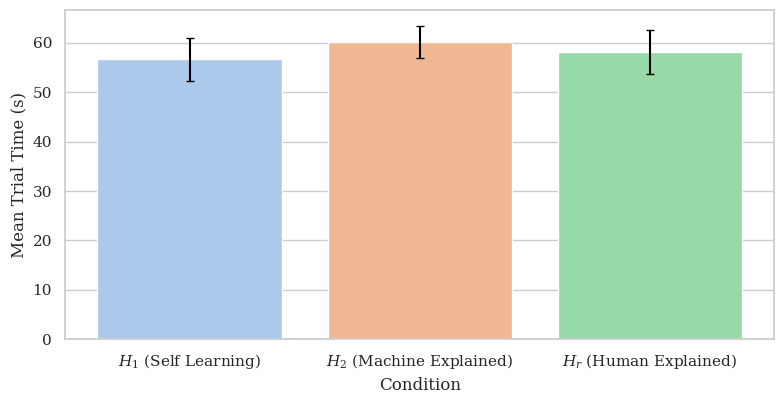

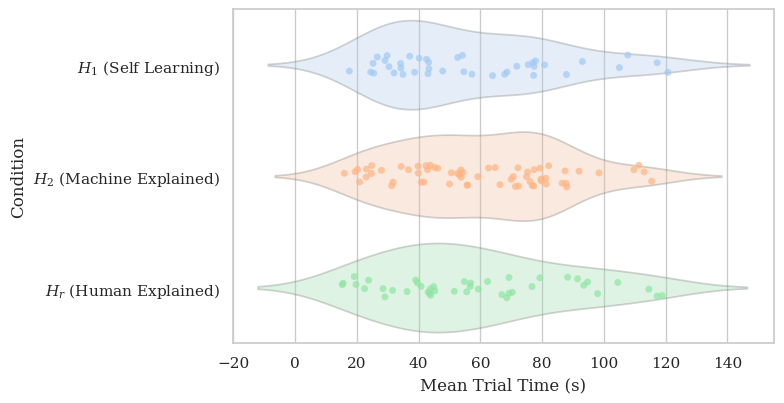

In [16]:
print(
    f"Mean time spent on trials: {data['t_mean_trial'].mean():.2f}, sd {data['t_mean_trial'].std():.2f}"
)
print("\tValues in first study: 38.20, sd 24.72")
print("\n==============================\n")

print("ANOVA analysing time spent on trials between conditions:")
anova_trial_time = pg.anova(data=data, dv="t_mean_trial", between="Condition")
pg.print_table(
    anova_trial_time, tablefmt="latex" if "save" in modifications else "grid"
)

# Bar plot: Mean trial time by condition
fig, ax = plt.subplots(figsize=(8, 4.2))
_data = data.groupby("Condition", observed=True)["t_mean_trial"].agg(["mean", "sem"]).reset_index()
sns.barplot(data=_data, x="Condition", y="mean", hue="Condition", palette=PALETTE, ax=ax, legend=False)
ax.errorbar(_data["Condition"], _data["mean"], yerr=_data["sem"], fmt='none', c='black', capsize=3)
ax.set_ylabel("Mean Trial Time (s)")
ax.set_xlabel("Condition")
plt.tight_layout()
plt.savefig("empirical_study/data_anlysis/figures/fig_trial_time.pdf") if "save" in modifications else None
plt.savefig("empirical_study/data_anlysis/figures/fig_trial_time.pgf") if "save" in modifications else None
plt.show()

# Strip plot with violin: Trial time distribution
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.violinplot(data=data, x="t_mean_trial", y="Condition", hue="Condition", palette=PALETTE, ax=ax, inner=None, alpha=0.3, legend=False)
sns.stripplot(data=data, x="t_mean_trial", y="Condition", hue="Condition", palette=PALETTE, ax=ax, alpha=0.7, legend=False, dodge=False)
ax.set_xlabel("Mean Trial Time (s)")
ax.set_ylabel("Condition")
plt.tight_layout()
plt.savefig("empirical_study/data_anlysis/figures/fig_t_scatter.pgf") if "save" in modifications else None

plt.show()

In [17]:
_data = pd.merge(data, demographic, "inner", "participant_id")
_data["t_to_submission"] = _data["Time taken"] - _data["t_total_calc"]
_data = _data[
    ["participant_id", "t_total_calc", "Time taken", "t_to_submission"]
].sort_values("t_to_submission", ascending=False)

pg.print_table(
    (_data.drop(["participant_id"], axis=1).median() / 60)
    .reset_index()
    .T.rename({0: "t_total_calc", 1: "Time taken", 2: "t_to_submission"}, axis=1)
    .drop("index"),
    tablefmt="latex" if "save" in modifications else "grid",
)

\begin{tabular}{rrr}
\hline
   t\_total\_calc &   Time taken &   t\_to\_submission \\
\hline
         37.942 &       43.150 &             1.092 \\
\hline
\end{tabular}



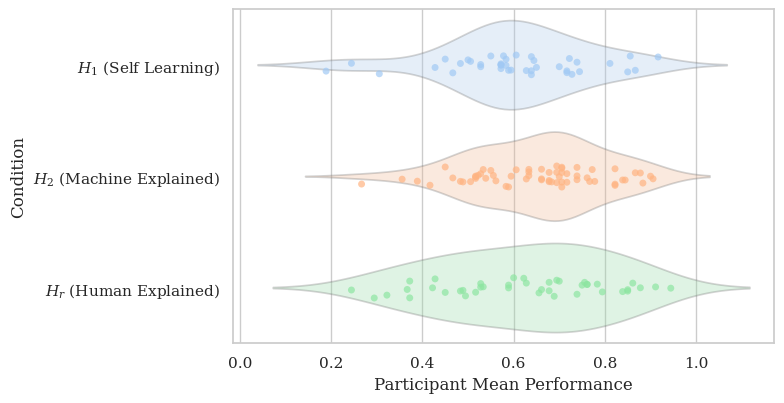

In [18]:
data["participant_mean"] = [row[trial_cols].mean() for _, row in data.iterrows()]

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.violinplot(data=data, x="participant_mean", y="Condition", hue="Condition", palette=PALETTE, ax=ax, inner=None, alpha=0.3, legend=False)
sns.stripplot(data=data, x="participant_mean", y="Condition", hue="Condition", palette=PALETTE, ax=ax, alpha=0.7, legend=False, dodge=False)
ax.set_xlabel("Participant Mean Performance")
ax.set_ylabel("Condition")
plt.tight_layout()
plt.savefig("empirical_study/data_anlysis/figures/fig_participant_mean.pgf") if "save" in modifications else None
plt.show()

## **Inference Statistics**

In [19]:
if "replace_missing_with_0" in modifications:
    data[trial_cols] = data[trial_cols].replace(-1.0, 0.0)

### **Domain Order Effect**

In [20]:
data_anova = data.reset_index().melt(
    id_vars=["participant_id", "domain_order"],
    value_vars=trial_cols,
    var_name="trial",
    value_name=metric_choice,
)

if "exclude_missing" in modifications:
    data_anova = data_anova[data_anova[metric_choice] != -1]

do_anova = pg.kruskal(data=data_anova, dv=metric_choice, between="domain_order")
pg.print_table(do_anova, tablefmt="latex" if "save" in modifications else "grid")

do_post_hoc = pg.pairwise.pairwise_tukey(data_anova, metric_choice, "domain_order", "cohen")
pg.print_table(do_post_hoc, tablefmt="latex" if "save" in modifications else "grid")

\begin{tabular}{lrrr}
\hline
 Source       &   ddof1 &     H &   p-unc \\
\hline
 domain\_order &       1 & 7.660 &   0.006 \\
\hline
\end{tabular}


POST HOC TESTS

\begin{tabular}{llrrrrrrr}
\hline
 A           & B           &   mean(A) &   mean(B) &   diff &    se &      T &   p-tukey &   cohen \\
\hline
 Water first & Lists first &     0.649 &     0.695 & -0.046 & 0.017 & -2.758 &     0.006 &  -0.122 \\
\hline
\end{tabular}



_**Note:** The domain-order randomizer still contained the draws from the first run, leading to a very unbalanced distribution between the two groups. This would be alleviated in the second batch, as the randomizer has now been updated to the current draws._

### **Hypothesis 1**

_**Condition effect in known domain**_

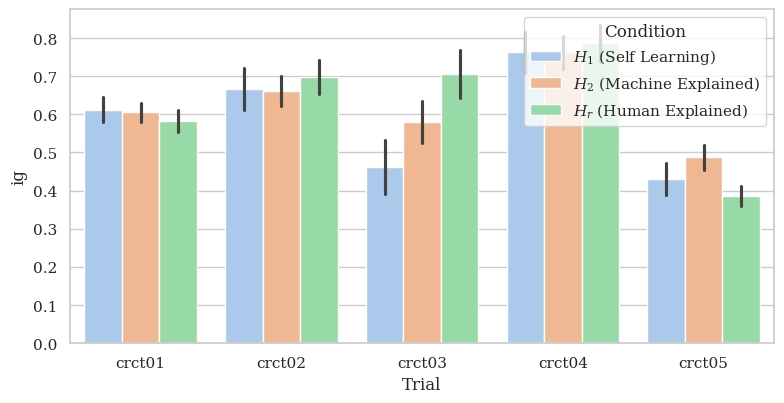

H-Test for condition effect in known domain (Circuits):

\begin{tabular}{lrrr}
\hline
 Source    &   ddof1 &     H &   p-unc \\
\hline
 Condition &       2 & 2.276 &   0.320 \\
\hline
\end{tabular}



In [21]:
crct_trials = [col for col in trial_cols if "crct" in col]
data_h1 = data.reset_index().melt(
    id_vars=["Condition", "participant_id"],
    value_vars=crct_trials,
    var_name="trial",
    value_name=metric_choice,
)

if "exclude_missing" in modifications:
    data_h1 = data_h1[data_h1[metric_choice] != -1]

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.barplot(data=data_h1, x="trial", y=metric_choice, hue="Condition", palette=PALETTE, ax=ax, errorbar="se")
ax.set_ylabel(metric_choice)
ax.set_xlabel("Trial")
ax.legend(title="Condition", loc="upper right")
plt.tight_layout()
plt.savefig("empirical_study/data_anlysis/figures/fig_h1.pdf") if "save" in modifications else None
plt.savefig("empirical_study/data_anlysis/figures/fig_h1.pgf") if "save" in modifications else None
plt.show()

h1_norm = pg.normality(data_h1, metric_choice, group="Condition")
h1_homvar = pg.homoscedasticity(data_h1, metric_choice, group="Condition")

h1_anova = pg.kruskal(data_h1, metric_choice, "Condition")
print("H-Test for condition effect in known domain (Circuits):\n")
pg.print_table(h1_anova, tablefmt="latex" if "save" in modifications else "grid")

# Store p-value for later correction
h1_p = h1_anova["p-unc"].values[0]

### **Hypothesis 2**

_**Condition effect in transfer domains**_

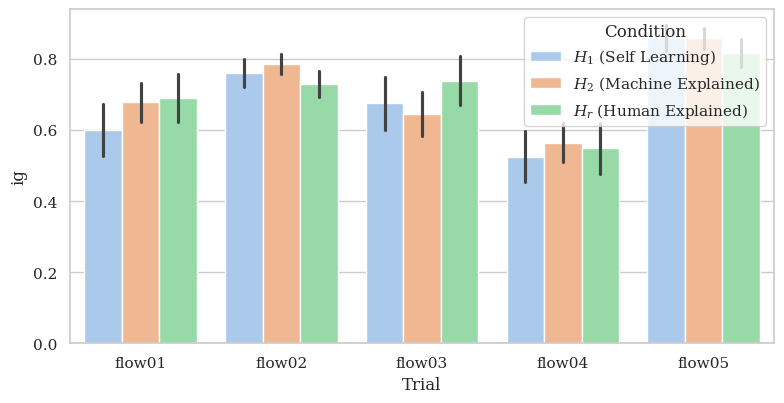

H-Test for condition effect in transfer domain (Flow):

\begin{tabular}{lrrr}
\hline
 Source    &   ddof1 &     H &   p-unc \\
\hline
 Condition &       2 & 0.334 &   0.846 \\
\hline
\end{tabular}



In [22]:
flow_trials = [col for col in trial_cols if "flow" in col]
data_h2_flow = data.reset_index().melt(
    id_vars=["Condition", "participant_id"],
    value_vars=flow_trials,
    var_name="trial",
    value_name=metric_choice,
)

if "exclude_missing" in modifications:
    data_h2_flow = data_h2_flow[data_h2_flow[metric_choice] != -1]

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.barplot(data=data_h2_flow, x="trial", y=metric_choice, hue="Condition", palette=PALETTE, ax=ax, errorbar="se")
ax.set_ylabel(metric_choice)
ax.set_xlabel("Trial")
ax.legend(title="Condition", loc="upper right")
plt.tight_layout()
plt.savefig("empirical_study/data_anlysis/figures/fig_h2_flow.pdf") if "save" in modifications else None
plt.savefig("empirical_study/data_anlysis/figures/fig_h2_flow.pgf") if "save" in modifications else None
plt.show()

h2_flow_norm = pg.normality(data_h2_flow, metric_choice, group="Condition")
h2_flow_homvar = pg.homoscedasticity(data_h2_flow, metric_choice, group="Condition")

h2_flow_anova = pg.kruskal(data_h2_flow, metric_choice, "Condition")
print("H-Test for condition effect in transfer domain (Flow):\n")
pg.print_table(h2_flow_anova, tablefmt="latex" if "save" in modifications else "grid")

# Store p-value for later correction
h2_flow_p = h2_flow_anova["p-unc"].values[0]

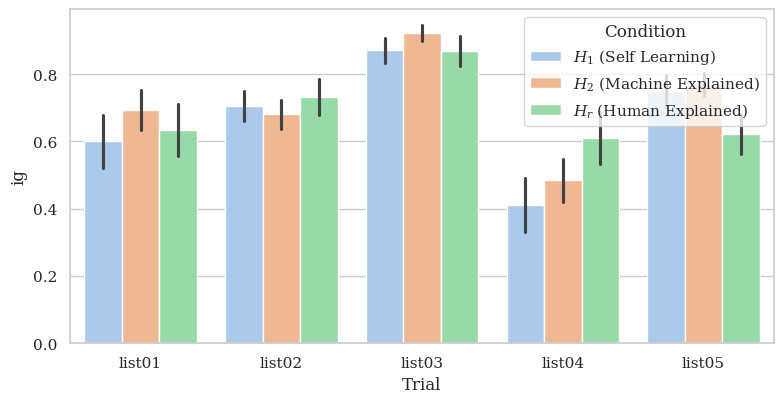

H-Test for condition effect in transfer domain (Lists):

\begin{tabular}{lrrr}
\hline
 Source    &   ddof1 &     H &   p-unc \\
\hline
 Condition &       2 & 1.769 &   0.413 \\
\hline
\end{tabular}



In [23]:
list_trials = [col for col in trial_cols if "list" in col]
data_h2_list = data.reset_index().melt(
    id_vars=["Condition", "participant_id"],
    value_vars=list_trials,
    var_name="trial",
    value_name=metric_choice,
)

if "exclude_missing" in modifications:
    data_h2_list = data_h2_list[data_h2_list[metric_choice] != -1]

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.barplot(data=data_h2_list, x="trial", y=metric_choice, hue="Condition", palette=PALETTE, ax=ax, errorbar="se")
ax.set_ylabel(metric_choice)
ax.set_xlabel("Trial")
ax.legend(title="Condition", loc="upper right")
plt.tight_layout()
plt.savefig("empirical_study/data_anlysis/figures/fig_h2_list.pdf") if "save" in modifications else None
plt.savefig("empirical_study/data_anlysis/figures/fig_h2_list.pgf") if "save" in modifications else None
plt.show()

h2_list_norm = pg.normality(data_h2_list, metric_choice, group="Condition")
h2_list_homvar = pg.homoscedasticity(data_h2_list, metric_choice, group="Condition")

h2_list_anova = pg.kruskal(data_h2_list, metric_choice, "Condition")
print("H-Test for condition effect in transfer domain (Lists):\n")
pg.print_table(h2_list_anova, tablefmt="latex" if "save" in modifications else "grid")

# Store p-value for later correction
h2_list_p = h2_list_anova["p-unc"].values[0]

In [24]:
from scipy.stats import false_discovery_control

hypothesis_pvals = {
    "H1 (Circuits)": h1_p,
    "H2a (Flow)": h2_flow_p,
    "H2b (Lists)": h2_list_p,
}

pvals_array = np.array(list(hypothesis_pvals.values()))
pvals_fdr = false_discovery_control(pvals_array, method='bh')
pvals_bonf = np.minimum(pvals_array * len(pvals_array), 1.0)

print("=" * 70)
print("MULTIPLE COMPARISON CORRECTION: Main Hypotheses (n=3 tests)")
print("=" * 70)
print(f"\n{'Hypothesis':<15} {'p (uncorr)':<12} {'p (FDR)':<12} {'p (Bonf)':<12} {'Sig':<6}")
print("-" * 70)

for i, (hyp, p_unc) in enumerate(hypothesis_pvals.items()):
    sig_fdr = "**" if pvals_fdr[i] < 0.05 else "*" if pvals_fdr[i] < 0.10 else ""
    print(f"{hyp:<15} {p_unc:<12.4f} {pvals_fdr[i]:<12.4f} {pvals_bonf[i]:<12.4f} {sig_fdr:<6}")

print("-" * 70)
print("\n** p < .05, * p < .10 after FDR correction")

MULTIPLE COMPARISON CORRECTION: Main Hypotheses (n=3 tests)

Hypothesis      p (uncorr)   p (FDR)      p (Bonf)     Sig   
----------------------------------------------------------------------
H1 (Circuits)   0.3205       0.6193       0.9614             
H2a (Flow)      0.8462       0.8462       1.0000             
H2b (Lists)     0.4129       0.6193       1.0000             
----------------------------------------------------------------------

** p < .05, * p < .10 after FDR correction


### **Mediator Variable: Effect of Reading Time in Training Phase on Average Performance in Trials**

In [25]:
data_mediator = data_backup.copy()
data_mediator["t_reading"] = np.mean(
    data_mediator[["t_LP02_expl", "t_LP03_expl", "t_LP04_expl"]], axis=1
)
data_mediator["performance_overall"] = np.mean(data_mediator[trial_cols], axis=1)
data_mediator["performance_crct"] = np.mean(data_mediator[crct_trials], axis=1)
data_mediator["performance_flow"] = np.mean(data_mediator[flow_trials], axis=1)
data_mediator["performance_list"] = np.mean(data_mediator[list_trials], axis=1)

# show only significant correlations of t_reading with performance
for col in [f"performance_{dom}" for dom in ("overall", "crct", "flow", "list")]:
    print(f"Reading time against {col}:\n") if (
        corr := pg.correlation.corr(data_mediator["t_reading"], data_mediator[col])
    )["p-val"].item() <= 0.05 else None
    pg.print_table(
        corr, tablefmt="latex" if "save" in modifications else "grid"
    ) if corr["p-val"].item() <= 0.05 else None

print("Regression t_reading ~ performance_overall:\n")
mediator_regr_overall = pg.linear_regression(
    data_mediator["t_reading"], data_mediator["performance_overall"]
)
pg.print_table(
    mediator_regr_overall, tablefmt="latex" if "save" in modifications else "grid"
)

print("Regression t_reading ~ performance_crct:\n")
mediator_regr_crct = pg.linear_regression(
    data_mediator["t_reading"], data_mediator["performance_crct"]
)
pg.print_table(
    mediator_regr_crct, tablefmt="latex" if "save" in modifications else "grid"
)

print("Regression t_reading ~ performance_flow:\n")
mediator_regr_flow = pg.linear_regression(
    data_mediator["t_reading"], data_mediator["performance_flow"]
)
pg.print_table(
    mediator_regr_flow, tablefmt="latex" if "save" in modifications else "grid"
)

print("Regression t_reading ~ performance_list:\n")
mediator_regr_list = pg.linear_regression(
    data_mediator["t_reading"], data_mediator["performance_list"]
)
pg.print_table(
    mediator_regr_list, tablefmt="latex" if "save" in modifications else "grid"
)

Regression t_reading ~ performance_overall:

\begin{tabular}{lrrrrrrrr}
\hline
 names     &   coef &    se &      T &   pval &    r2 &   adj\_r2 &   CI[2.5\%] &   CI[97.5\%] \\
\hline
 Intercept &  0.630 & 0.016 & 38.467 &  0.000 & 0.000 &   -0.007 &      0.598 &       0.662 \\
 t\_reading & -0.000 & 0.000 & -0.025 &  0.980 & 0.000 &   -0.007 &     -0.000 &       0.000 \\
\hline
\end{tabular}

Regression t_reading ~ performance_crct:

\begin{tabular}{lrrrrrrrr}
\hline
 names     &   coef &    se &      T &   pval &    r2 &   adj\_r2 &   CI[2.5\%] &   CI[97.5\%] \\
\hline
 Intercept &  0.607 & 0.017 & 34.820 &  0.000 & 0.006 &   -0.001 &      0.572 &       0.641 \\
 t\_reading & -0.000 & 0.000 & -0.892 &  0.374 & 0.006 &   -0.001 &     -0.000 &       0.000 \\
\hline
\end{tabular}

Regression t_reading ~ performance_flow:

\begin{tabular}{lrrrrrrrr}
\hline
 names     &   coef &    se &      T &   pval &    r2 &   adj\_r2 &   CI[2.5\%] &   CI[97.5\%] \\
\hline
 Intercept &  0.677 & 0.023 

In [26]:
data_mediator["t_reading"].mean(), data_mediator["t_reading"].std()

(np.float64(90.30439814814814), np.float64(124.90801017613742))

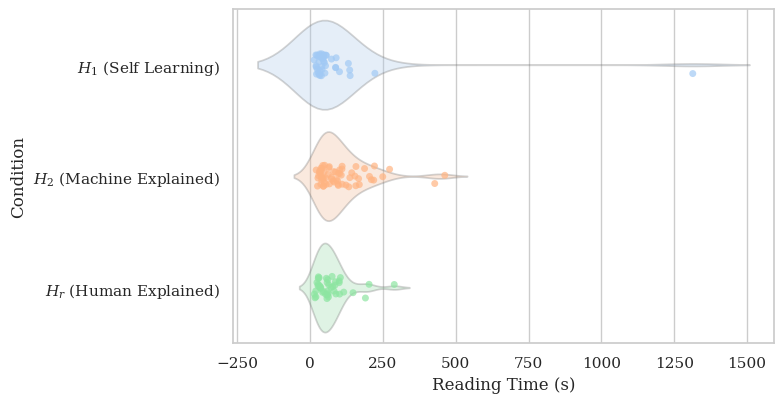

In [27]:
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.violinplot(data=data_mediator, x="t_reading", y="Condition", hue="Condition", palette=PALETTE, ax=ax, inner=None, alpha=0.3, legend=False)
sns.stripplot(data=data_mediator, x="t_reading", y="Condition", hue="Condition", palette=PALETTE, ax=ax, alpha=0.7, legend=False)
ax.set_xlabel("Reading Time (s)")
ax.set_ylabel("Condition")
plt.tight_layout()
plt.savefig("empirical_study/data_anlysis/figures/fig_reading_time.pgf") if "save" in modifications else None
plt.show()

In [28]:
for grp in ("overall", "crct", "flow", "list"):
    match grp:
        case "overall":
            val_var = trial_cols
        case "crct":
            val_var = crct_trials
        case "flow":
            val_var = flow_trials
        case "list":
            val_var = list_trials

    data_ancova = data_mediator.reset_index().melt(
        id_vars=["Condition", "participant_id", "t_reading"],
        value_vars=val_var,
        var_name="trial",
        value_name=metric_choice,
    )

    if "exclude_missing" in modifications:
        data_ancova = data_ancova[data_ancova[metric_choice] != -1]

    anc = pg.ancova(data_ancova, metric_choice, "Condition", "t_reading")
    pg.print_table(anc, tablefmt="latex" if "save" in modifications else "grid")


ANOVA SUMMARY

\begin{tabular}{lrrrrr}
\hline
 Source    &      SS &   DF &       F &   p-unc &     np2 \\
\hline
 Condition &   0.491 &    2 &   1.720 &   0.179 &   0.002 \\
 t\_reading &   0.313 &    1 &   2.198 &   0.138 &   0.001 \\
 Residual  & 300.537 & 2107 & nan     & nan     & nan     \\
\hline
\end{tabular}


ANOVA SUMMARY

\begin{tabular}{lrrrrr}
\hline
 Source    &     SS &   DF &       F &   p-unc &     np2 \\
\hline
 Condition &  0.250 &    2 &   1.140 &   0.321 &   0.003 \\
 t\_reading &  0.205 &    1 &   1.865 &   0.172 &   0.003 \\
 Residual  & 77.637 &  708 & nan     & nan     & nan     \\
\hline
\end{tabular}


ANOVA SUMMARY

\begin{tabular}{lrrrrr}
\hline
 Source    &      SS &   DF &       F &   p-unc &     np2 \\
\hline
 Condition &   0.072 &    2 &   0.236 &   0.790 &   0.001 \\
 t\_reading &   0.050 &    1 &   0.326 &   0.568 &   0.000 \\
 Residual  & 108.474 &  706 & nan     & nan     & nan     \\
\hline
\end{tabular}


ANOVA SUMMARY

\begin{tabular}{lrrrrr}
\

In [29]:
data_ancova = data_mediator.reset_index().melt(
    id_vars=["Condition", "participant_id", "t_reading"],
    value_vars=crct_trials,
    var_name="trial",
    value_name=metric_choice,
)

if "exclude_missing" in modifications:
    data_ancova = data_ancova[data_ancova[metric_choice] != -1]

pg.print_table(
    pg.ancova(data_ancova, metric_choice, "Condition", "t_reading"), tablefmt="grid"
)

pg.print_table(
    pg.pairwise.pairwise_tukey(data_ancova, metric_choice, "Condition", "cohen"),
    tablefmt="grid",
)


ANOVA SUMMARY

+-----------+--------+------+---------+---------+---------+
| Source    |     SS |   DF |       F |   p-unc |     np2 |
+===========+========+======+=========+=========+=========+
| Condition |  0.250 |    2 |   1.140 |   0.321 |   0.003 |
+-----------+--------+------+---------+---------+---------+
| t_reading |  0.205 |    1 |   1.865 |   0.172 |   0.003 |
+-----------+--------+------+---------+---------+---------+
| Residual  | 77.637 |  708 | nan     | nan     | nan     |
+-----------+--------+------+---------+---------+---------+


POST HOC TESTS

+---------------------------+---------------------------+-----------+-----------+--------+-------+--------+-----------+---------+
| A                         | B                         |   mean(A) |   mean(B) |   diff |    se |      T |   p-tukey |   cohen |
+===========================+===========================+===========+===========+========+=======+========+===========+=========+
| $H_1$ (Self Learning)     | $H_2$ 

## Exploratory Analyses (Post-Hoc)

FDR correction applied across **6 pairwise comparisons** (Short vs Control and Short vs Long for each domain).

---

### Finding 1: Short explanations benefit high-ability learners in Circuits

| Metric | Value |
|--------|-------|
| p | **.046** |
| Cohen's d | 1.08 |

In [30]:
all_trials = crct_trials + flow_trials + list_trials
participant_overall = data.copy()

for t in all_trials:
    participant_overall[t] = participant_overall[t].replace(-1, np.nan)

participant_overall["overall_mean"] = participant_overall[all_trials].mean(axis=1)
first_trials = ["crct01", "flow01", "list01"]
participant_overall["first_trial_mean"] = participant_overall[first_trials].mean(axis=1)

median_baseline = participant_overall["first_trial_mean"].median()
participant_overall["ability_group"] = np.where(
    participant_overall["first_trial_mean"] <= median_baseline, "Low Baseline", "High Baseline"
)

for domain, trials in [("circuits", crct_trials), ("flow", flow_trials), ("lists", list_trials)]:
    participant_overall[f"{domain}_mean"] = participant_overall[trials].mean(axis=1)

baseline_kw = pg.kruskal(data=participant_overall, dv="first_trial_mean", between="Condition")

print("BASELINE ANALYSIS")
print(f"  Median baseline: {median_baseline:.3f}")
print(f"  High Baseline: n={len(participant_overall[participant_overall['ability_group']=='High Baseline'])}")
print(f"  Low Baseline: n={len(participant_overall[participant_overall['ability_group']=='Low Baseline'])}")
print(f"  Balance check: H={baseline_kw['H'].values[0]:.2f}, p={baseline_kw['p-unc'].values[0]:.3f}")

BASELINE ANALYSIS
  Median baseline: 0.667
  High Baseline: n=56
  Low Baseline: n=88
  Balance check: H=1.92, p=0.383


In [31]:
print("INITIAL PERFORMANCE × CONDITION INTERACTION")
print("="*60)

exploratory_pvals = []
exploratory_labels = []

for domain, label in [("circuits", DOMAIN_NAMES["circuits"]), ("flow", DOMAIN_NAMES["flow"]), ("lists", DOMAIN_NAMES["lists"])]:
    domain_mean = f"{domain}_mean"
    
    anova_2way = pg.anova(data=participant_overall, dv=domain_mean, between=["Condition", "ability_group"])
    interaction_p = anova_2way[anova_2way["Source"] == "Condition * ability_group"]["p-unc"].values[0]
    
    high_baseline = participant_overall[participant_overall["ability_group"] == "High Baseline"]
    kw = pg.kruskal(data=high_baseline, dv=domain_mean, between="Condition")
    kw_p = kw['p-unc'].values[0]
    
    print(f"\n{label}:")
    print(f"  Interaction (Condition × Ability): p={interaction_p:.4f}")
    print(f"  High Baseline condition effect: H={kw['H'].values[0]:.2f}, p={kw_p:.4f}")

INITIAL PERFORMANCE × CONDITION INTERACTION

Electrical Circuits:
  Interaction (Condition × Ability): p=0.0207
  High Baseline condition effect: H=8.23, p=0.0164

Waterflow:
  Interaction (Condition × Ability): p=0.5613
  High Baseline condition effect: H=0.90, p=0.6368

List Binary Search:
  Interaction (Condition × Ability): p=0.6167
  High Baseline condition effect: H=1.50, p=0.4735


In [32]:
print("POST-HOC: High Baseline Circuits (Finding 1)")
print("="*60)

high_baseline = participant_overall[participant_overall["ability_group"] == "High Baseline"]
control = high_baseline[high_baseline["Condition"] == CONDITION_NAMES["H1"]]["circuits_mean"]
short_exp = high_baseline[high_baseline["Condition"] == CONDITION_NAMES["Hr"]]["circuits_mean"]  # Hr = Human/Short
long_exp = high_baseline[high_baseline["Condition"] == CONDITION_NAMES["H2"]]["circuits_mean"]   # H2 = Machine/Long

def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled = np.sqrt(((n1-1)*g1.var(ddof=1) + (n2-1)*g2.var(ddof=1)) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled if pooled > 0 else 0

mw_short_ctrl = pg.mwu(short_exp, control)
mw_short_long = pg.mwu(short_exp, long_exp)
mw_long_ctrl = pg.mwu(long_exp, control)

d_short_ctrl = cohens_d(short_exp, control)
d_short_long = cohens_d(short_exp, long_exp)

exploratory_pvals.extend([mw_short_ctrl['p-val'].values[0], mw_short_long['p-val'].values[0]])
exploratory_labels.extend(["Circuits_Short_vs_Ctrl", "Circuits_Short_vs_Long"])

print(f"\nCondition Means (n per group):")
print(f"  Control: {control.mean():.3f} (n={len(control)})")
print(f"  Long: {long_exp.mean():.3f} (n={len(long_exp)})")
print(f"  Short: {short_exp.mean():.3f} (n={len(short_exp)})")
print(f"\nPairwise comparisons (uncorrected):")
print(f"  Short vs Control: U={mw_short_ctrl['U-val'].values[0]:.0f}, p={mw_short_ctrl['p-val'].values[0]:.4f}, d={d_short_ctrl:.2f}")
print(f"  Short vs Long: p={mw_short_long['p-val'].values[0]:.4f}, d={d_short_long:.2f}")
print(f"  Long vs Control: p={mw_long_ctrl['p-val'].values[0]:.4f}")
print(f"\n→ FDR correction applied in final summary cell")

POST-HOC: High Baseline Circuits (Finding 1)

Condition Means (n per group):
  Control: 0.647 (n=12)
  Long: 0.633 (n=28)
  Short: 0.771 (n=16)

Pairwise comparisons (uncorrected):
  Short vs Control: U=141, p=0.0381, d=1.08
  Short vs Long: p=0.0064, d=0.97
  Long vs Control: p=0.7449

→ FDR correction applied in final summary cell


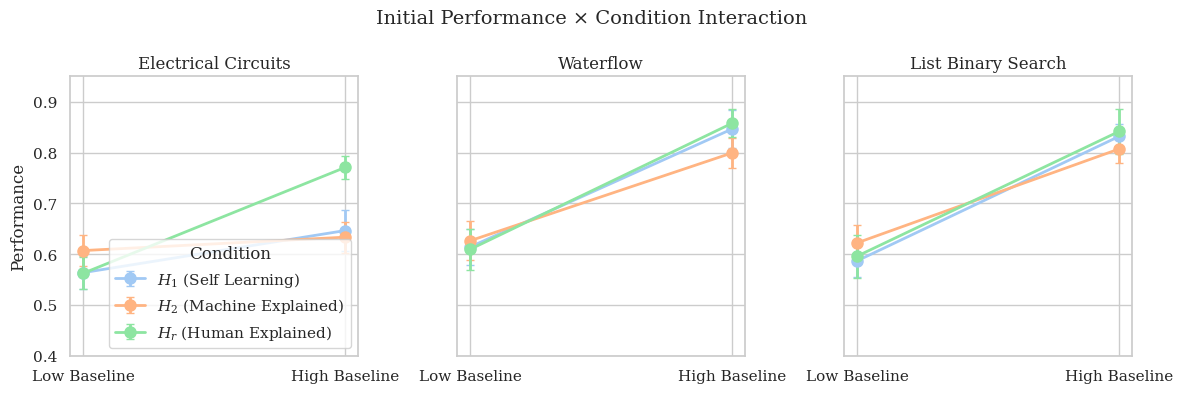

In [33]:
# Initial Performance × Condition Interaction plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
_pal = sns.color_palette(PALETTE)
palette = {CONDITION_NAMES[k]: _pal[i] for i, k in enumerate(CONDITION_ORDER)}
ability_groups = ["Low Baseline", "High Baseline"]
conditions = [CONDITION_NAMES[k] for k in CONDITION_ORDER]

for ax, (domain, title) in zip(axes, [("circuits", DOMAIN_NAMES["circuits"]), ("flow", DOMAIN_NAMES["flow"]), ("lists", DOMAIN_NAMES["lists"])]):
    domain_mean = f"{domain}_mean"
    for cond in conditions:
        means = [participant_overall[(participant_overall["Condition"] == cond) & 
                 (participant_overall["ability_group"] == ab)][domain_mean].mean() for ab in ability_groups]
        sems = [participant_overall[(participant_overall["Condition"] == cond) & 
                (participant_overall["ability_group"] == ab)][domain_mean].sem() for ab in ability_groups]
        ax.errorbar(ability_groups, means, yerr=sems, marker='o', markersize=8, linewidth=2, 
                   label=cond, color=palette[cond], capsize=3)
    ax.set_title(title)
    ax.set_ylim(0.4, 0.95)
    ax.set_ylabel("Performance" if ax == axes[0] else "")

axes[0].legend(title="Condition", loc="lower right")
fig.suptitle("Initial Performance × Condition Interaction", fontsize=14)
plt.tight_layout()
plt.savefig("empirical_study/data_anlysis/figures/fig_interaction.pgf") if "save" in modifications else None
plt.show()

### Finding 2: Short explanations benefit high-ability engaged readers in Lists

| Metric | Value |
|--------|-------|
| p | **.046** |
| Cohen's d | 1.35 |

In [34]:
flow_reading_cols = [f"t_flow{i:02d}" for i in range(1, 6)]
list_reading_cols = [f"t_list{i:02d}" for i in range(1, 6)]

for col in flow_reading_cols + list_reading_cols:
    if col in data.columns:
        participant_overall[col] = data.groupby("participant_id")[col].mean().values

participant_overall["flow_reading_time"] = participant_overall[flow_reading_cols].mean(axis=1)
participant_overall["lists_reading_time"] = participant_overall[list_reading_cols].mean(axis=1)

median_flow_read = participant_overall["flow_reading_time"].median()
median_lists_read = participant_overall["lists_reading_time"].median()

participant_overall["flow_engagement"] = np.where(participant_overall["flow_reading_time"] >= median_flow_read, "Engaged", "Quick")
participant_overall["lists_engagement"] = np.where(participant_overall["lists_reading_time"] >= median_lists_read, "Engaged", "Quick")

print("ENGAGEMENT CLASSIFICATION")
print(f"  Flow median reading time: {median_flow_read:.1f}s")
print(f"  Lists median reading time: {median_lists_read:.1f}s")

ENGAGEMENT CLASSIFICATION
  Flow median reading time: 62.0s
  Lists median reading time: 27.0s


In [35]:
print("BASELINE × ENGAGEMENT ANALYSIS")
print("="*60)

results = []
for domain, perf_col, engage_col, label in [("flow", "flow_mean", "flow_engagement", "Flow"),
                                              ("lists", "lists_mean", "lists_engagement", "Lists")]:
    print(f"\n{label}:")
    for ability in ["High Baseline", "Low Baseline"]:
        for engagement in ["Engaged", "Quick"]:
            subset = participant_overall[(participant_overall["ability_group"] == ability) & 
                                         (participant_overall[engage_col] == engagement)]
            if len(subset) >= 8:
                kw = pg.kruskal(data=subset, dv=perf_col, between="Condition")
                p = kw['p-unc'].values[0]
                sig = "**" if p < 0.05 else "*" if p < 0.1 else ""
                print(f"  {ability.split()[0]}+{engagement}: n={len(subset)}, p={p:.4f} {sig}")
                results.append({"Domain": label, "Baseline": ability.split()[0], "Engagement": engagement, "n": len(subset), "p": p})

BASELINE × ENGAGEMENT ANALYSIS

Flow:
  High+Engaged: n=26, p=0.5127 
  High+Quick: n=30, p=0.2247 
  Low+Engaged: n=48, p=0.9563 
  Low+Quick: n=40, p=0.8319 

Lists:
  High+Engaged: n=28, p=0.0237 **
  High+Quick: n=28, p=0.7572 
  Low+Engaged: n=44, p=0.2393 
  Low+Quick: n=44, p=0.8312 


In [36]:
print("POST-HOC: High Baseline + Engaged Lists (Finding 2)")
print("="*60)

lists_high_engaged = participant_overall[(participant_overall["ability_group"] == "High Baseline") &
                                          (participant_overall["lists_engagement"] == "Engaged")]

ctrl = lists_high_engaged[lists_high_engaged["Condition"] == CONDITION_NAMES["H1"]]["lists_mean"]
short_exp = lists_high_engaged[lists_high_engaged["Condition"] == CONDITION_NAMES["Hr"]]["lists_mean"]  # Hr = Human/Short
long_exp = lists_high_engaged[lists_high_engaged["Condition"] == CONDITION_NAMES["H2"]]["lists_mean"]   # H2 = Machine/Long

mw_short_ctrl = pg.mwu(short_exp, ctrl)
mw_short_long = pg.mwu(short_exp, long_exp)
d_short_ctrl = cohens_d(short_exp, ctrl)
d_short_long = cohens_d(short_exp, long_exp)

exploratory_pvals.extend([mw_short_ctrl['p-val'].values[0], mw_short_long['p-val'].values[0]])
exploratory_labels.extend(["Lists_Short_vs_Ctrl", "Lists_Short_vs_Long"])

print(f"\nCondition Means (n per group):")
print(f"  Control: {ctrl.mean():.3f} (n={len(ctrl)})")
print(f"  Long: {long_exp.mean():.3f} (n={len(long_exp)})")
print(f"  Short: {short_exp.mean():.3f} (n={len(short_exp)})")
print(f"\nPairwise comparisons (uncorrected):")
print(f"  Short vs Control: p={mw_short_ctrl['p-val'].values[0]:.4f}, d={d_short_ctrl:.2f}")
print(f"  Short vs Long: p={mw_short_long['p-val'].values[0]:.4f}, d={d_short_long:.2f}")
print(f"\n→ FDR correction applied in final summary cell")

POST-HOC: High Baseline + Engaged Lists (Finding 2)

Condition Means (n per group):
  Control: 0.848 (n=8)
  Long: 0.825 (n=12)
  Short: 0.950 (n=8)

Pairwise comparisons (uncorrected):
  Short vs Control: p=0.0245, d=1.35
  Short vs Long: p=0.0166, d=1.31

→ FDR correction applied in final summary cell


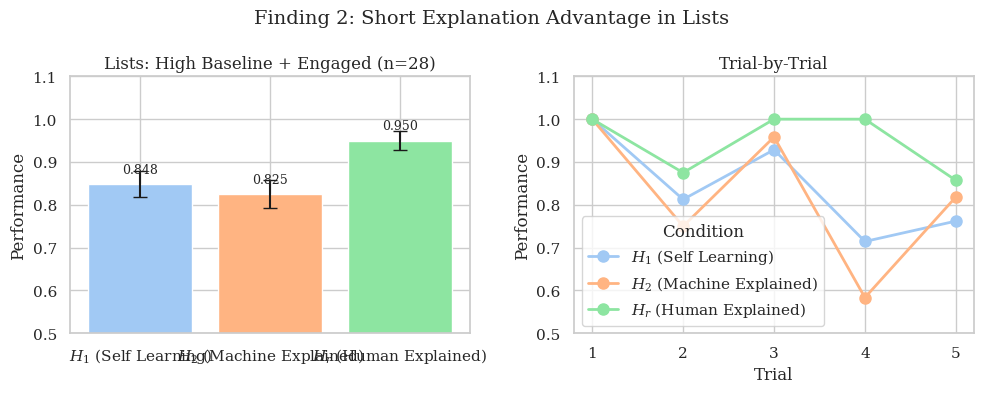

In [37]:
# Finding 2: Lists High Baseline + Engaged
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
conditions = [CONDITION_NAMES[k] for k in CONDITION_ORDER]
_pal = sns.color_palette(PALETTE)
palette = {CONDITION_NAMES[k]: _pal[i] for i, k in enumerate(CONDITION_ORDER)}
colors_list = _pal[:3]

# Left: Bar plot
means = [lists_high_engaged[lists_high_engaged["Condition"] == c]["lists_mean"].mean() for c in conditions]
sems = [lists_high_engaged[lists_high_engaged["Condition"] == c]["lists_mean"].sem() for c in conditions]
bars = axes[0].bar(conditions, means, color=colors_list, yerr=sems, capsize=5)
for bar, m in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{m:.3f}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel("Performance")
axes[0].set_ylim(0.5, 1.1)
axes[0].set_title("Lists: High Baseline + Engaged (n=28)")

# Right: Trial-by-trial line plot
for cond in conditions:
    trial_means = [lists_high_engaged[lists_high_engaged["Condition"] == cond][t].mean() for t in list_trials]
    axes[1].plot([1,2,3,4,5], trial_means, marker='o', markersize=8, linewidth=2, label=cond, color=palette[cond])
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("Performance")
axes[1].set_ylim(0.5, 1.1)
axes[1].set_title("Trial-by-Trial")
axes[1].legend(title="Condition")

fig.suptitle("Finding 2: Short Explanation Advantage in Lists", fontsize=14)
plt.tight_layout()
plt.savefig("empirical_study/data_anlysis/figures/fig_finding2.pgf") if "save" in modifications else None
plt.show()

### Finding 3: Short explanations show trend for high-ability quick readers in Flow

| Metric | Value |
|--------|-------|
| p | .052 |
| Cohen's d | 1.26 |

Analysis restricted to difficult trials (mean < 0.70) to mitigate ceiling effects.

In [38]:
print("DIFFICULT TRIAL IDENTIFICATION (threshold: mean < 0.70)")
print("="*60)

flow_trials = ["flow01", "flow02", "flow03", "flow04", "flow05"]
trial_difficulty = {t: participant_overall[t].mean() for t in flow_trials}

for trial, perf in trial_difficulty.items():
    status = "DIFFICULT" if perf < 0.70 else "Easy"
    print(f"  {trial}: {perf:.3f} → {status}")

flow_difficult_trials = [t for t in flow_trials if trial_difficulty[t] < 0.70]
participant_overall["flow_difficult_mean"] = participant_overall[flow_difficult_trials].mean(axis=1)
print(f"\n→ Difficult trials: {flow_difficult_trials}")

DIFFICULT TRIAL IDENTIFICATION (threshold: mean < 0.70)
  flow01: 0.660 → DIFFICULT
  flow02: 0.763 → Easy
  flow03: 0.681 → DIFFICULT
  flow04: 0.549 → DIFFICULT
  flow05: 0.847 → Easy

→ Difficult trials: ['flow01', 'flow03', 'flow04']


In [39]:
print("FLOW DIFFICULT TRIALS × BASELINE × ENGAGEMENT")
print("="*60)

for ability in ["High Baseline", "Low Baseline"]:
    ability_data = participant_overall[participant_overall["ability_group"] == ability]
    print(f"\n{ability}:")
    for engagement in ["Quick", "Engaged"]:
        subset = ability_data[ability_data["flow_engagement"] == engagement]
        if len(subset) >= 10:
            kw = pg.kruskal(data=subset, dv="flow_difficult_mean", between="Condition")
            p = kw['p-unc'].values[0]
            sig = "**" if p < 0.05 else "*" if p < 0.1 else ""
            print(f"  {engagement}: n={len(subset)}, p={p:.4f} {sig}")

FLOW DIFFICULT TRIALS × BASELINE × ENGAGEMENT

High Baseline:
  Quick: n=30, p=0.0694 *
  Engaged: n=26, p=0.4415 

Low Baseline:
  Quick: n=40, p=0.7119 
  Engaged: n=48, p=0.8089 


In [40]:
print("POST-HOC: High Baseline + Quick Flow (Finding 3)")
print("="*60)

high_quick = participant_overall[(participant_overall["ability_group"] == "High Baseline") & 
                                  (participant_overall["flow_engagement"] == "Quick")]

ctrl_hq = high_quick[high_quick["Condition"] == CONDITION_NAMES["H1"]]["flow_difficult_mean"]
short_hq = high_quick[high_quick["Condition"] == CONDITION_NAMES["Hr"]]["flow_difficult_mean"]  # Hr = Human/Short
long_hq = high_quick[high_quick["Condition"] == CONDITION_NAMES["H2"]]["flow_difficult_mean"]   # H2 = Machine/Long

mw_hq_short_ctrl = pg.mwu(short_hq, ctrl_hq)
mw_hq_short_long = pg.mwu(short_hq, long_hq)
d_hq = cohens_d(short_hq, ctrl_hq)
d_hq_long = cohens_d(short_hq, long_hq)

exploratory_pvals.extend([mw_hq_short_ctrl['p-val'].values[0], mw_hq_short_long['p-val'].values[0]])
exploratory_labels.extend(["Flow_Short_vs_Ctrl", "Flow_Short_vs_Long"])

print(f"\nCondition Means (n per group):")
print(f"  Control: {ctrl_hq.mean():.3f} (n={len(ctrl_hq)})")
print(f"  Long: {long_hq.mean():.3f} (n={len(long_hq)})")
print(f"  Short: {short_hq.mean():.3f} (n={len(short_hq)})")
print(f"\nPairwise comparisons (uncorrected):")
print(f"  Short vs Control: p={mw_hq_short_ctrl['p-val'].values[0]:.4f}, d={d_hq:.2f}")
print(f"  Short vs Long: p={mw_hq_short_long['p-val'].values[0]:.4f}, d={d_hq_long:.2f}")
print(f"\n→ FDR correction applied in final summary cell")

POST-HOC: High Baseline + Quick Flow (Finding 3)

Condition Means (n per group):
  Control: 0.778 (n=6)
  Long: 0.740 (n=16)
  Short: 0.958 (n=8)

Pairwise comparisons (uncorrected):
  Short vs Control: p=0.0524, d=1.26
  Short vs Long: p=0.0316, d=0.93

→ FDR correction applied in final summary cell


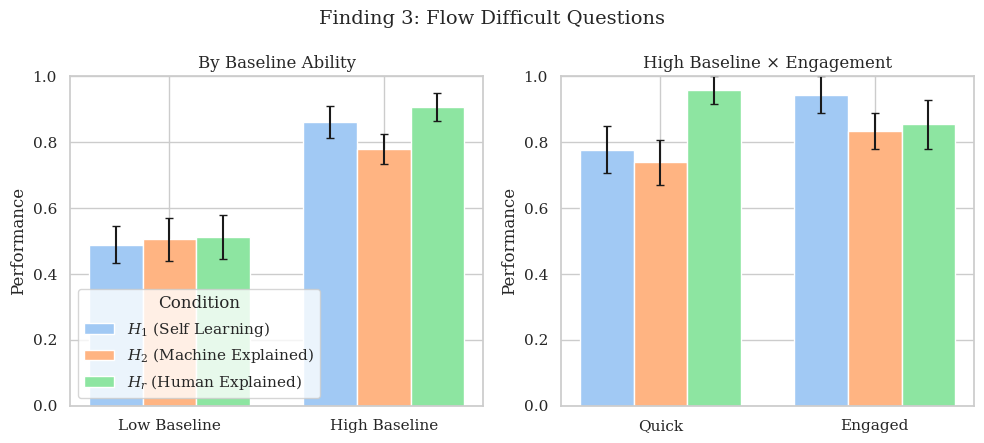

In [41]:
# Finding 3: Flow Difficult Questions
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
conditions = [CONDITION_NAMES[k] for k in CONDITION_ORDER]
_pal = sns.color_palette(PALETTE)
palette = {CONDITION_NAMES[k]: _pal[i] for i, k in enumerate(CONDITION_ORDER)}
colors_list = _pal[:3]
x_positions = np.arange(2)
width = 0.25

# Left: By Baseline Ability
for j, cond in enumerate(conditions):
    means = []
    sems = []
    for ability in ["Low Baseline", "High Baseline"]:
        ability_data = participant_overall[participant_overall["ability_group"] == ability]
        cond_data = ability_data[ability_data["Condition"] == cond]["flow_difficult_mean"]
        means.append(cond_data.mean())
        sems.append(cond_data.sem())
    axes[0].bar(x_positions + j*width, means, width, yerr=sems, label=cond, color=palette[cond], capsize=3)
axes[0].set_xticks(x_positions + width)
axes[0].set_xticklabels(["Low Baseline", "High Baseline"])
axes[0].set_ylabel("Performance")
axes[0].set_ylim(0, 1)
axes[0].set_title("By Baseline Ability")
axes[0].legend(title="Condition")

# Right: High Baseline × Engagement
high_base = participant_overall[participant_overall["ability_group"] == "High Baseline"]
x_positions = np.arange(2)
for j, cond in enumerate(conditions):
    means = []
    sems = []
    for engagement in ["Quick", "Engaged"]:
        eng_data = high_base[high_base["flow_engagement"] == engagement]
        cond_data = eng_data[eng_data["Condition"] == cond]["flow_difficult_mean"]
        if len(cond_data) > 0:
            means.append(cond_data.mean())
            sems.append(cond_data.sem())
        else:
            means.append(0)
            sems.append(0)
    axes[1].bar(x_positions + j*width, means, width, yerr=sems, label=cond, color=palette[cond], capsize=3)
axes[1].set_xticks(x_positions + width)
axes[1].set_xticklabels(["Quick", "Engaged"])
axes[1].set_ylabel("Performance")
axes[1].set_ylim(0, 1)
axes[1].set_title("High Baseline × Engagement")

fig.suptitle("Finding 3: Flow Difficult Questions", fontsize=14)
plt.tight_layout()
plt.savefig("empirical_study/data_anlysis/figures/fig_finding3.pgf") if "save" in modifications else None
plt.show()

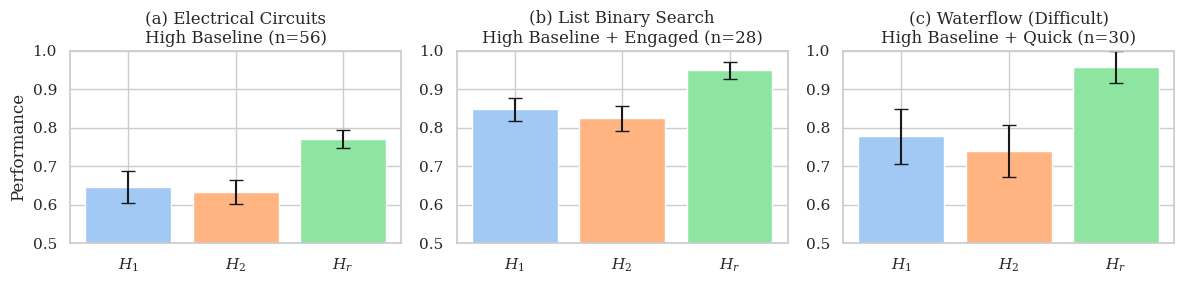

In [46]:
# Combined figure for all 3 exploratory findings
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
_pal = sns.color_palette(PALETTE)
colors_list = _pal[:3]
conditions = [CONDITION_NAMES[k] for k in CONDITION_ORDER]

# Finding 1: Circuits - High Baseline
high_baseline = participant_overall[participant_overall["ability_group"] == "High Baseline"]
means_f1 = [high_baseline[high_baseline["Condition"] == c]["circuits_mean"].mean() for c in conditions]
sems_f1 = [high_baseline[high_baseline["Condition"] == c]["circuits_mean"].sem() for c in conditions]
bars = axes[0].bar(range(3), means_f1, color=colors_list, yerr=sems_f1, capsize=5)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels([CONDITION_LABELS[k] for k in CONDITION_ORDER])
axes[0].set_ylabel("Performance")
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title(f"(a) {DOMAIN_NAMES['circuits']}\nHigh Baseline (n={len(high_baseline)})")

# Finding 2: Lists - High Baseline + Engaged
lists_high_engaged = participant_overall[(participant_overall["ability_group"] == "High Baseline") &
                                          (participant_overall["lists_engagement"] == "Engaged")]
means_f2 = [lists_high_engaged[lists_high_engaged["Condition"] == c]["lists_mean"].mean() for c in conditions]
sems_f2 = [lists_high_engaged[lists_high_engaged["Condition"] == c]["lists_mean"].sem() for c in conditions]
bars = axes[1].bar(range(3), means_f2, color=colors_list, yerr=sems_f2, capsize=5)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels([CONDITION_LABELS[k] for k in CONDITION_ORDER])
# axes[1].set_ylabel("Performance")
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title(f"(b) {DOMAIN_NAMES['lists']}\nHigh Baseline + Engaged (n={len(lists_high_engaged)})")

# Finding 3: Flow - High Baseline + Quick (Difficult Trials)
high_quick = participant_overall[(participant_overall["ability_group"] == "High Baseline") & 
                                  (participant_overall["flow_engagement"] == "Quick")]
means_f3 = [high_quick[high_quick["Condition"] == c]["flow_difficult_mean"].mean() for c in conditions]
sems_f3 = [high_quick[high_quick["Condition"] == c]["flow_difficult_mean"].sem() for c in conditions]
bars = axes[2].bar(range(3), means_f3, color=colors_list, yerr=sems_f3, capsize=5)
axes[2].set_xticks(range(3))
axes[2].set_xticklabels([CONDITION_LABELS[k] for k in CONDITION_ORDER])
# axes[2].set_ylabel("Performance")
axes[2].set_ylim(0.5, 1.0)
axes[2].set_title(f"(c) {DOMAIN_NAMES['flow']} (Difficult)\nHigh Baseline + Quick (n={len(high_quick)})")

plt.tight_layout()
plt.savefig("empirical_study/data_anlysis/figures/fig_exploratory_findings.pdf") if "save" in modifications else None
plt.savefig("empirical_study/data_anlysis/figures/fig_exploratory_findings.pgf") if "save" in modifications else None
plt.show()

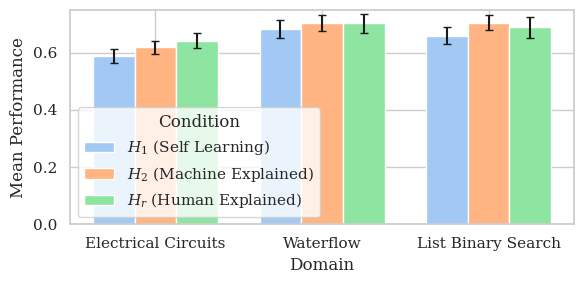

In [43]:
fig, ax = plt.subplots(figsize=(6, 3))
conditions = [CONDITION_NAMES[k] for k in CONDITION_ORDER]
domains = [DOMAIN_NAMES["circuits"], DOMAIN_NAMES["flow"], DOMAIN_NAMES["lists"]]
domain_cols = ["circuits_mean", "flow_mean", "lists_mean"]
x = np.arange(len(domains))
width = 0.25
_pal = sns.color_palette(PALETTE)

for i, cond in enumerate(conditions):
    cond_data = participant_overall[participant_overall["Condition"] == cond]
    means = [cond_data[col].mean() for col in domain_cols]
    sems = [cond_data[col].sem() for col in domain_cols]
    ax.bar(x + i*width, means, width, yerr=sems, label=cond, color=_pal[i], capsize=3)

ax.set_ylabel("Mean Performance")
ax.set_xlabel("Domain")
ax.set_xticks(x + width)
ax.set_xticklabels(domains)
ax.set_ylim(0.0, 0.75)
ax.legend(title="Condition")
plt.tight_layout()
plt.savefig("empirical_study/data_anlysis/figures/fig_overall_by_domain.pgf") if "save" in modifications else None
plt.show()

In [44]:
print("=" * 60)
print("MULTIPLE COMPARISON CORRECTION (FDR, n=6 tests)")
print("=" * 60)

exploratory_pvals_array = np.array(exploratory_pvals)
exploratory_pvals_fdr = false_discovery_control(exploratory_pvals_array, method='bh')

print(f"\n{'Test':<25} {'p (FDR)':<12} {'Sig':<6}")
print("-" * 60)

for i, label in enumerate(exploratory_labels):
    p_fdr = exploratory_pvals_fdr[i]
    sig = "**" if p_fdr < 0.05 else "*" if p_fdr < 0.10 else ""
    print(f"{label:<25} {p_fdr:<12.4f} {sig:<6}")

print("-" * 60)
print("\n** p < .05, * p < .10")

key_findings = [
    ("Circuits_Short_vs_Ctrl", "Finding 1: Circuits (High Baseline)"),
    ("Lists_Short_vs_Ctrl", "Finding 2: Lists (High Baseline + Engaged)"),
    ("Flow_Short_vs_Ctrl", "Finding 3: Flow (High Baseline + Quick)"),
]

MULTIPLE COMPARISON CORRECTION (FDR, n=6 tests)

Test                      p (FDR)      Sig   
------------------------------------------------------------
Circuits_Short_vs_Ctrl    0.0457       **    
Circuits_Short_vs_Long    0.0384       **    
Lists_Short_vs_Ctrl       0.0457       **    
Lists_Short_vs_Long       0.0457       **    
Flow_Short_vs_Ctrl        0.0524       *     
Flow_Short_vs_Long        0.0457       **    
------------------------------------------------------------

** p < .05, * p < .10
